# 2. User generation discussion

## 1. Move from system capability to user demand

We now move from what the system can provide to what users ask from it.

This notebook adds demand in a simple way. The aim is not to build a full traffic model. The aim is to create a day-varying load signal so we can study how the scheduler and the power amplifier choices respond as demand rises and falls.


In [1]:
import sys
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
%matplotlib inline

repo_root = Path.cwd().resolve()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent

for path in (repo_root / "notebooks", repo_root / "src"):
    resolved = str(path.resolve())
    if resolved not in sys.path:
        sys.path.insert(0, resolved)

from configs.day_cycle import DEFAULT_SYNTHETIC_SESSION_GENERATION_CONFIG
from helpers.user_generation_helpers import UserGenerationHelpers

DOC_IMG_DIR = repo_root / "img"
DOC_IMG_DIR.mkdir(parents=True, exist_ok=True)

# Notebook-wide visual identity: change this once to rerun under the other institutional theme.
helper = UserGenerationHelpers(theme="aalto_elec")


In [2]:
load_curve_csv = repo_root / "data" / "half_load_curve.csv"
config = DEFAULT_SYNTHETIC_SESSION_GENERATION_CONFIG

artifacts = helper.build_artifacts(
    load_curve_csv=load_curve_csv,
    config=config,
)


## 2. Define how demand changes over the day

We start with a day load curve taken from an operator micro-cell traffic profile. The horizontal axis shows time across one day, and the vertical axis shows total offered load. The main point here is that the load changes over time.

Those changes matter because they change the scheduler problem. In low-load periods, the scheduler has more room to choose among feasible options. In high-load periods, the system is more constrained.

To use the curve in the simulator, we divide it into 15-minute bins. Each bin gives the total traffic that must be represented in that interval.


Saved figure to C:\Users\henry\Documents\Masters Thesis\code\img\day_cycle_macro_load_curve.png


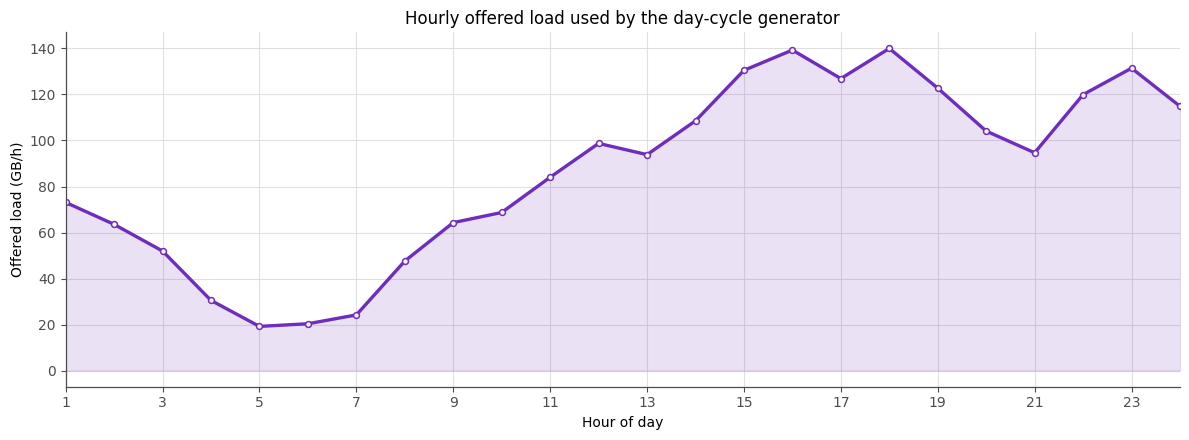

In [3]:
hourly_fig, hourly_ax = helper.plot_hourly_offered_load(
    artifacts,
    export_path=DOC_IMG_DIR / "day_cycle_macro_load_curve.png",
)


Saved figure to C:\Users\henry\Documents\Masters Thesis\code\img\day_cycle_15_minute_target_bins.png


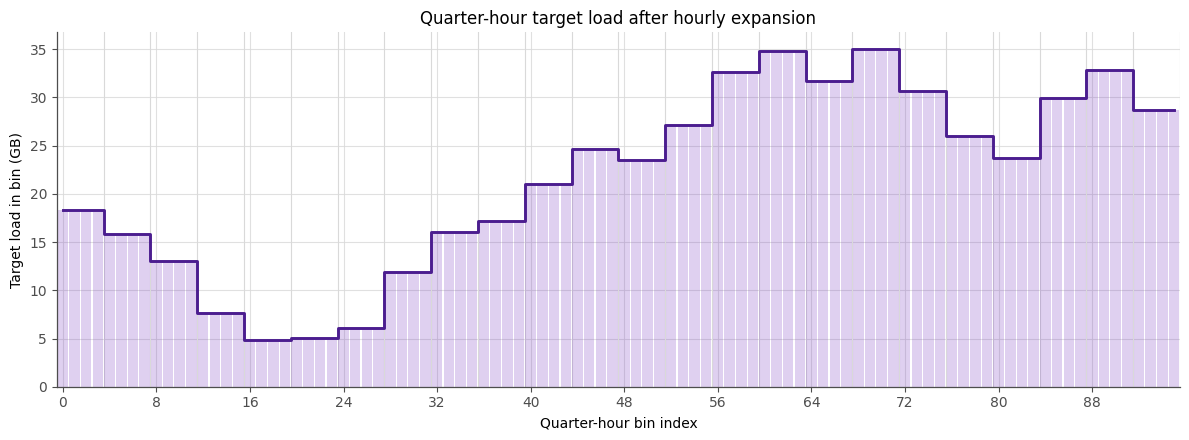

In [4]:
target_fig, target_ax = helper.plot_target_bins(
    artifacts,
    export_path=DOC_IMG_DIR / "day_cycle_15_minute_target_bins.png",
)


## 3. Translate the aggregate load into user sessions

The next step is to convert the bin-level load into user sessions.

The generator fills each 15-minute bin with sampled sessions. Each session is drawn from a fixed set of distances, total data amounts, and durations. A session contributes a constant rate over its lifetime. Sampling continues until the remaining demand in a bin is smaller than the smallest session size.

The first block plot shows how the demand is built, not a scheduler output. Rectangle width shows session duration. Color shows required rate. Vertical stacking is only used to make overlapping sessions visible.

The second plot keeps the same layout but colors sessions by distance. This makes the user mix visible across the day.

Together, the two plots show that similar total load can still lead to different scheduler inputs, because the rate mix and the distance mix may change.


Saved figure to C:\Users\henry\Documents\Masters Thesis\code\img\day_cycle_session_blocks.png
Saved figure to C:\Users\henry\Documents\Masters Thesis\code\img\day_cycle_session_blocks_by_distance.png


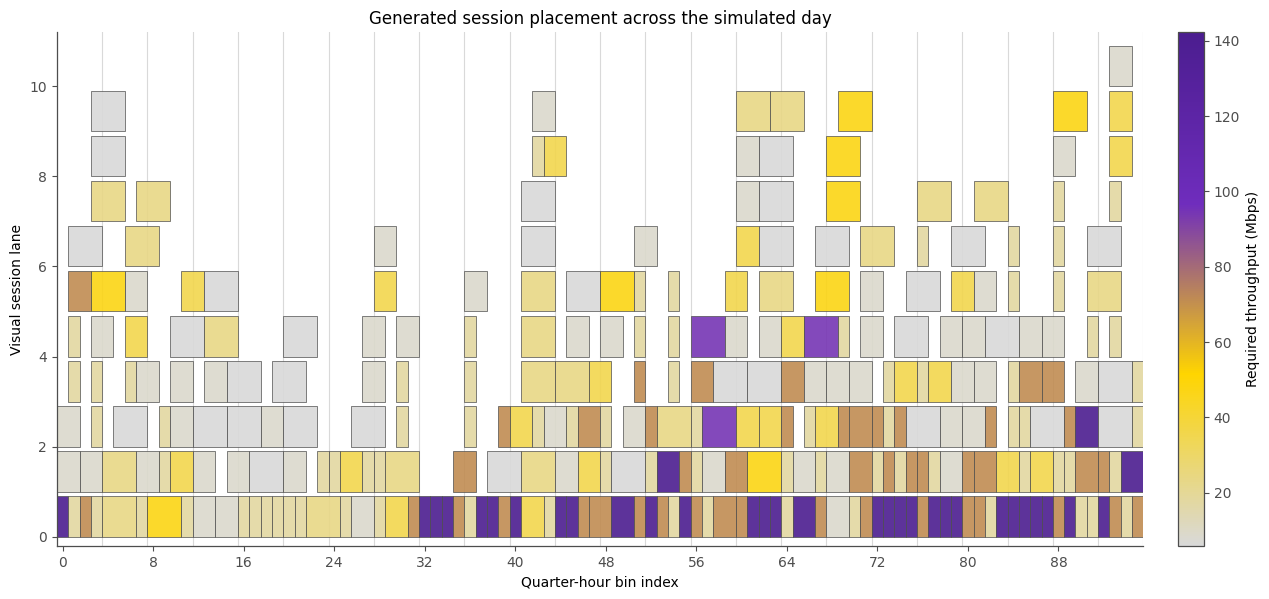

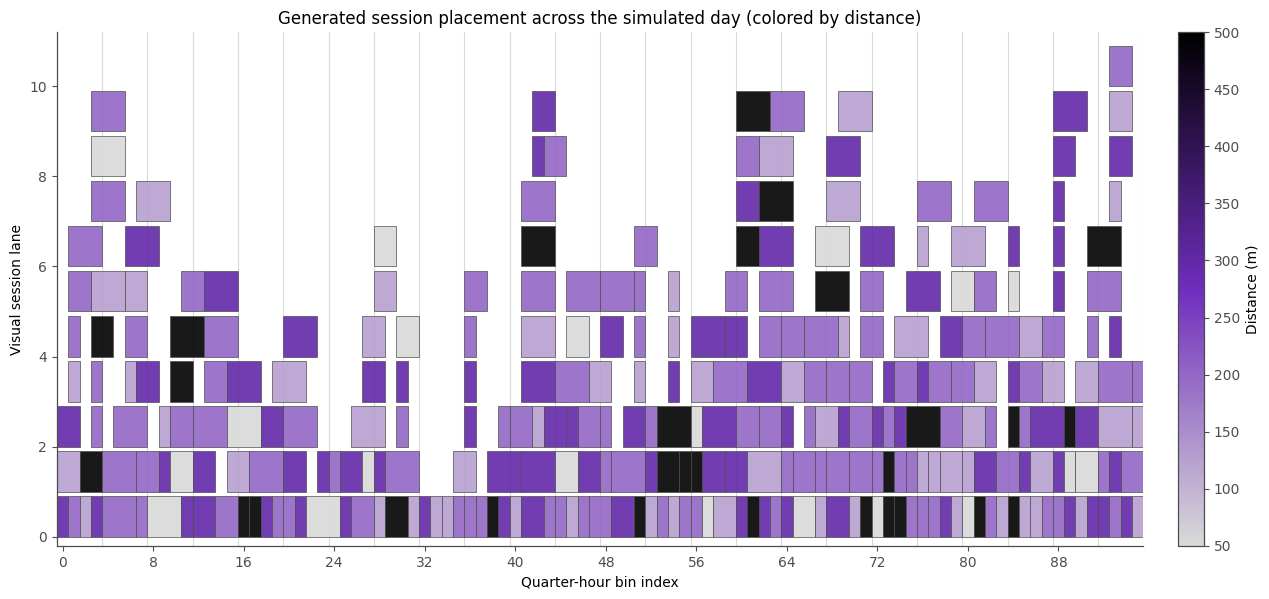

In [5]:
session_rate_fig, session_rate_ax = helper.plot_session_layout(
    artifacts,
    color_by="throughput",
    export_path=DOC_IMG_DIR / "day_cycle_session_blocks.png",
)

session_distance_fig, session_distance_ax = helper.plot_session_layout(
    artifacts,
    color_by="distance",
    export_path=DOC_IMG_DIR / "day_cycle_session_blocks_by_distance.png",
)


## 4. Expand sessions into per-bin scheduler rows

At this stage, we have full sessions, but the scheduler does not work on full sessions directly.

Instead, each session is expanded into one row for each bin it occupies. Each row keeps only the fields the scheduler needs: `user_id`, `distance_m`, and `required_rate_bps`.

The example below shows one session that spans three bins and the three scheduler rows created from it. This matches the scheduler time step: in each bin, the scheduler receives the active users and their fixed rate requests.


In [6]:
helper.display_session_expansion(artifacts)


Session ID,Distance (m),Total data (GB),Start time,Stop time,Duration (bins),Duration (min),Required rate (Mbps)
175,200,2.00,00:15,01:00,3,45,5.93


Bin index,User ID,Distance (m),Required rate (Mbps)
1,175,200,5.93
2,175,200,5.93
3,175,200,5.93


## 5. Complete the user-generation layer

After this expansion, the user-generation layer is complete.

One day load curve has now been converted into 96 scheduler-ready user batches, one for each 15-minute bin. The validation plot below shows two points. First, the rebuilt bin traffic follows the discretized target curve closely, with only a small residual caused by the minimum session size. Second, the number of active users still changes with session overlap, so bins with similar total load can still contain different user sets.

This output becomes the input to the next layer. For each bin, the model now has a set of users, each described by a distance and a required rate.


Saved figure to C:\Users\henry\Documents\Masters Thesis\code\img\day_cycle_target_vs_generated_bins.png


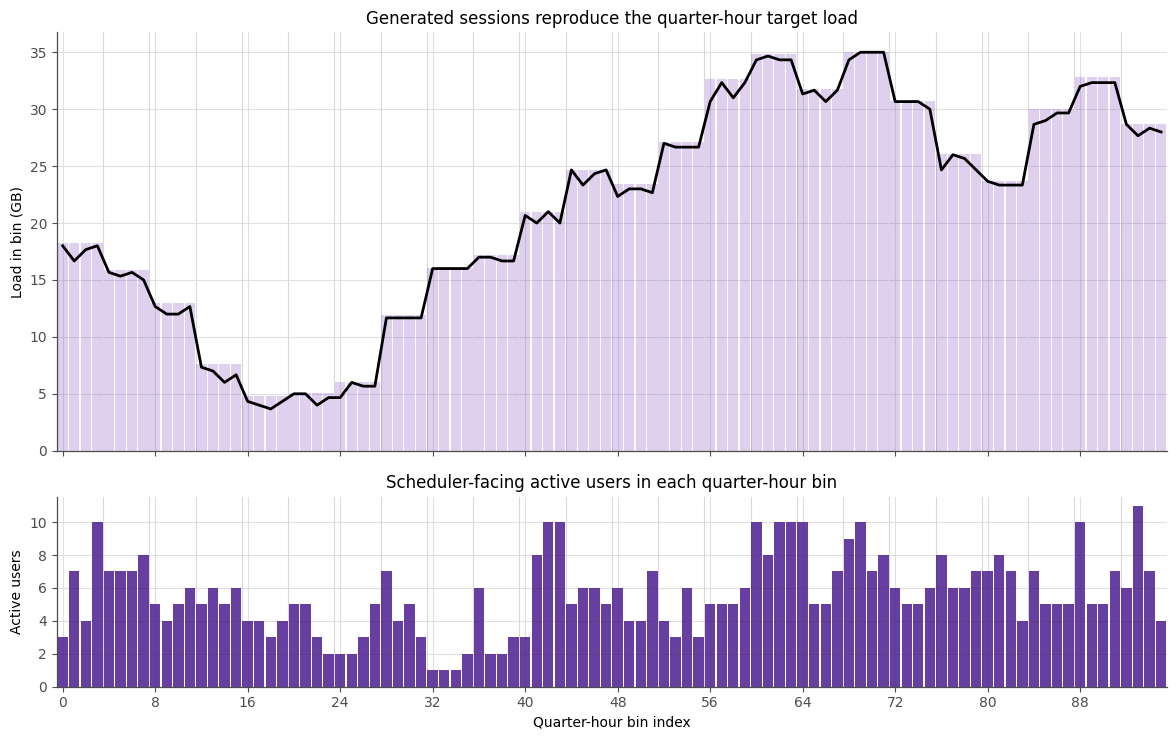

In [7]:
validation_fig, validation_axes = helper.plot_day_validation(
    artifacts,
    export_path=DOC_IMG_DIR / "day_cycle_target_vs_generated_bins.png",
)


Each active user can then query the precomputed candidate frontier for its distance and retrieve the feasible transmission options. The next notebook takes one active bin from this day table, gathers the per-user candidate sets, and prepares the batch artifact used by the TDMA scheduler.
